# AI-Powered Cattle Disease Classification using CNN-Based Transfer Learning with EfficientNetB0

## Deep Learning System for Early Detection of Foot and Mouth Disease(FMD), Lumpy Skin Disease(LSD), Mastitis, and Healthy Cattle
**Model:** EfficientNetB0 (Transfer Learning) | **Classes:** FMD, Healthy, Lumpy Skin, Mastitis | **Framework:** TensorFlow / Keras

## 1. Import the Required Libraries

In [1]:

!pip cache purge
!pip install -r requirements.txt


Files removed: 6
     ---------------------------------------- 0.0/455.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/455.9 MB ? eta -:--:--
     -------------------------------------- 0.0/455.9 MB 217.9 kB/s eta 0:34:53
     -------------------------------------- 0.0/455.9 MB 281.8 kB/s eta 0:26:58
     -------------------------------------- 0.0/455.9 MB 281.8 kB/s eta 0:26:58
     -------------------------------------- 0.0/455.9 MB 281.8 kB/s eta 0:26:58
     -------------------------------------- 0.1/455.9 MB 245.8 kB/s eta 0:30:55
     -------------------------------------- 0.1/455.9 MB 328.2 kB/s eta 0:23:09
     -------------------------------------- 0.1/455.9 MB 328.2 kB/s eta 0:23:09
     -------------------------------------- 0.1/455.9 MB 327.9 kB/s eta 0:23:11
     -------------------------------------- 0.2/455.9 MB 406.9 kB/s eta 0:18:41
     -------------------------------------- 0.2/455.9 MB 436.6 kB/s eta 0:17:24
     --------------------------------


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import random
import os
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import (
    Dense, Conv2D, MaxPool2D, Flatten,
    Dropout, BatchNormalization, GlobalAveragePooling2D,
    RandomFlip, RandomRotation, RandomZoom, Rescaling, RandomContrast, RandomBrightness
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img
from sklearn.utils.class_weight import compute_class_weight

In [3]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

## 2. Data Preprocessing

### 2.1 Configuration

In [4]:
train_dir = r"New-Cattle-Diseasee-3/train"
valid_dir = r"New-Cattle-Diseasee-3/valid"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

### 2.2 Data Augmentation Pipeline

In [27]:
data_augmentation = Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.2),
    RandomZoom(0.15),
    RandomContrast(0.2),
    # RandomBrightness removed - causes EagerTensor bug in TF 2.10.0
], name="data_augmentation")

### 2.3 Load the Data 

In [6]:
training_set = image_dataset_from_directory(
    directory=train_dir,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE, 
    shuffle=True,
    seed=42
)

validation_set = image_dataset_from_directory(
    directory=valid_dir,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False, 
    seed=42
)

# Get class names before any transforms
class_names = training_set.class_names
num_classes = len(class_names)
print(f"Classes ({num_classes}): {class_names}")

Found 2800 files belonging to 4 classes.
Found 598 files belonging to 4 classes.
Classes (4): ['fmd', 'healthy', 'lumpy skin', 'mastitis']


### 2.4 Performance Optimization

In [7]:
# Cache and prefetch for much faster training
AUTOTUNE = tf.data.AUTOTUNE

training_set = training_set.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_set = validation_set.cache().prefetch(buffer_size=AUTOTUNE)

### 2.5 Visualizing Sample Images in the Dataset

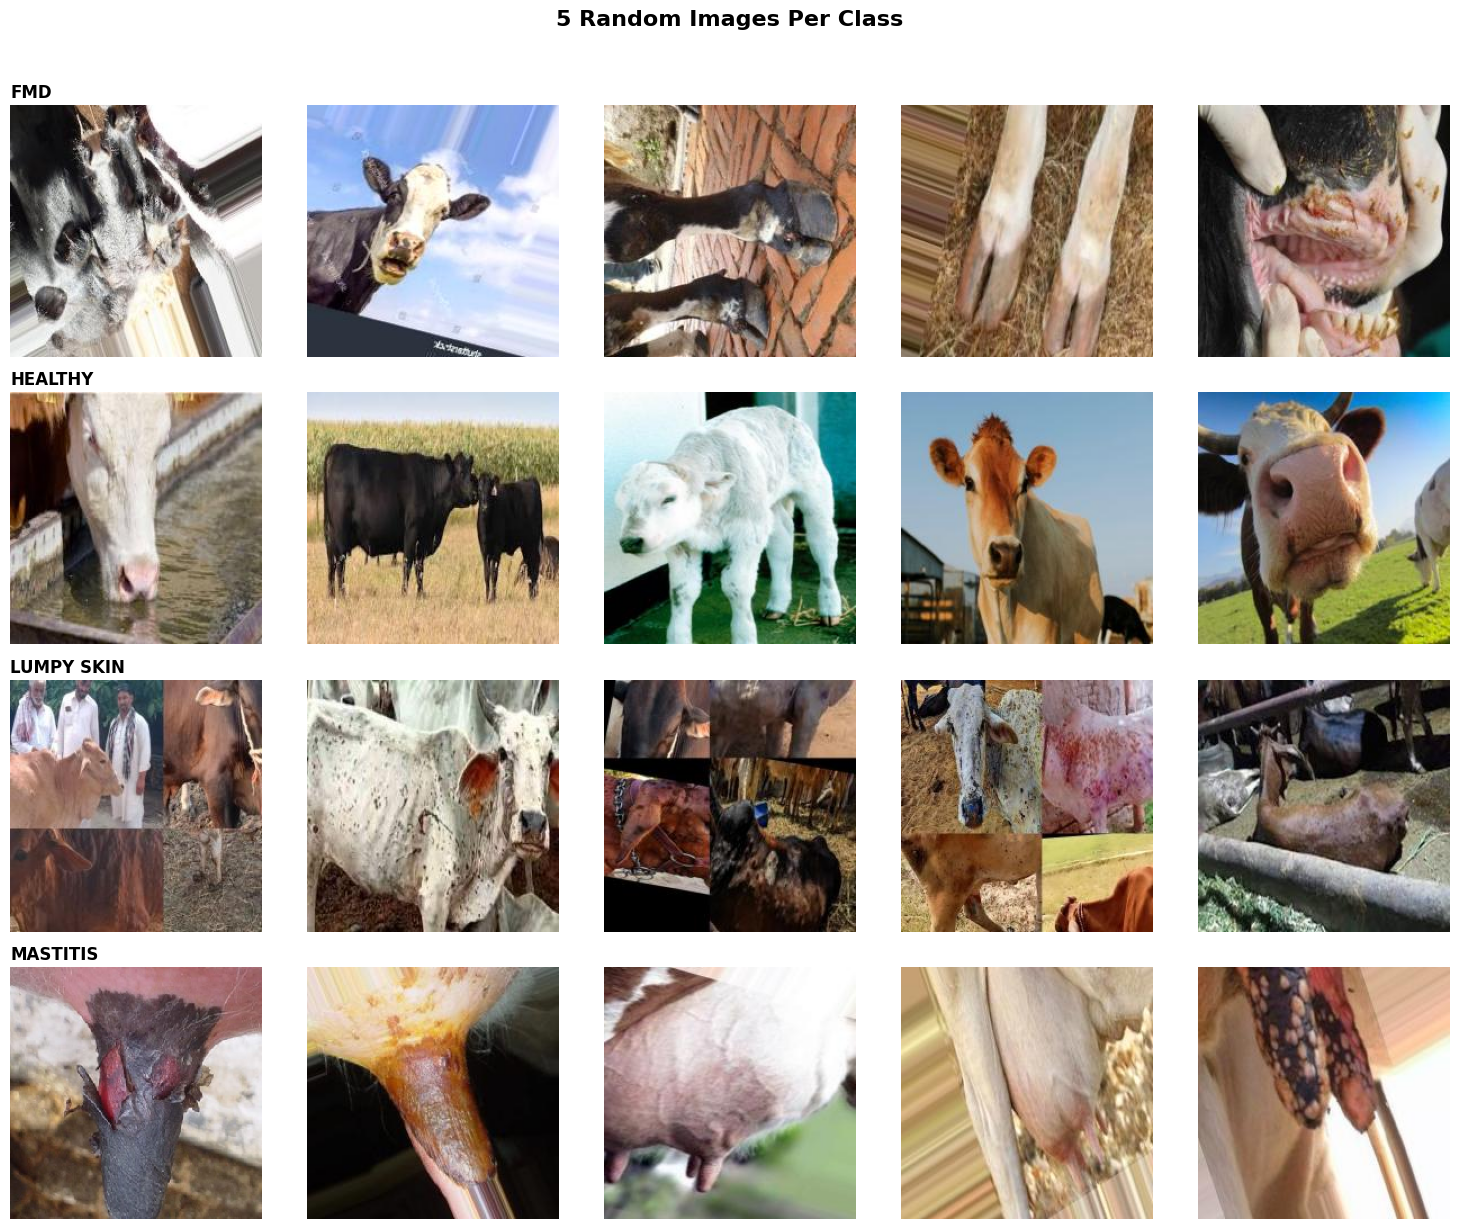

In [8]:
BASE_DIR = 'New-Cattle-Diseasee-3'
class_names = ['fmd', 'healthy', 'lumpy skin', 'mastitis']

fig, axes = plt.subplots(len(class_names), 5, figsize=(15, 12))
fig.suptitle('5 Random Images Per Class', fontsize=16, fontweight='bold', y=1.02)

for row, class_name in enumerate(class_names):
    train_path = os.path.join(BASE_DIR, 'train', class_name)
    
    # Get all images and pick 5 random ones
    all_images = [f for f in os.listdir(train_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random_images = random.sample(all_images, 5)
    
    for col, img_file in enumerate(random_images):
        img = load_img(os.path.join(train_path, img_file), target_size=(224, 224))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        
        # Only show class name on first image of each row
        if col == 0:
            axes[row, col].set_title(class_name.upper(), fontsize=12,
                                      fontweight='bold', loc='left', pad=5)

plt.tight_layout()
plt.show()

### 2.6 Augementation Preview 

In [9]:
# Get one sample image per class
sample_images = {}
for images, labels in training_set.take(1):
    for i in range(len(labels)):
        class_idx = np.argmax(labels[i].numpy())
        class_name = class_names[class_idx]
        if class_name not in sample_images:
            sample_images[class_name] = images[i]
    if len(sample_images) == len(class_names):
        break

# Define individual transformations with labels
transforms = [
    ("Original",           lambda x: x),
    ("Horizontal Flip",    lambda x: tf.image.flip_left_right(x)),
    ("Vertical Flip",      lambda x: tf.image.flip_up_down(x)),
    ("Rotation (20°)",     lambda x: RandomRotation(0.2)(tf.expand_dims(x, 0), training=True)[0]),
    ("Zoom (15%)",         lambda x: RandomZoom(0.15)(tf.expand_dims(x, 0), training=True)[0]),
    ("Contrast",           lambda x: RandomContrast(0.2)(tf.expand_dims(x, 0), training=True)[0]),
    ("Brightness",         lambda x: RandomBrightness(0.2)(tf.expand_dims(x, 0), training=True)[0]),
]

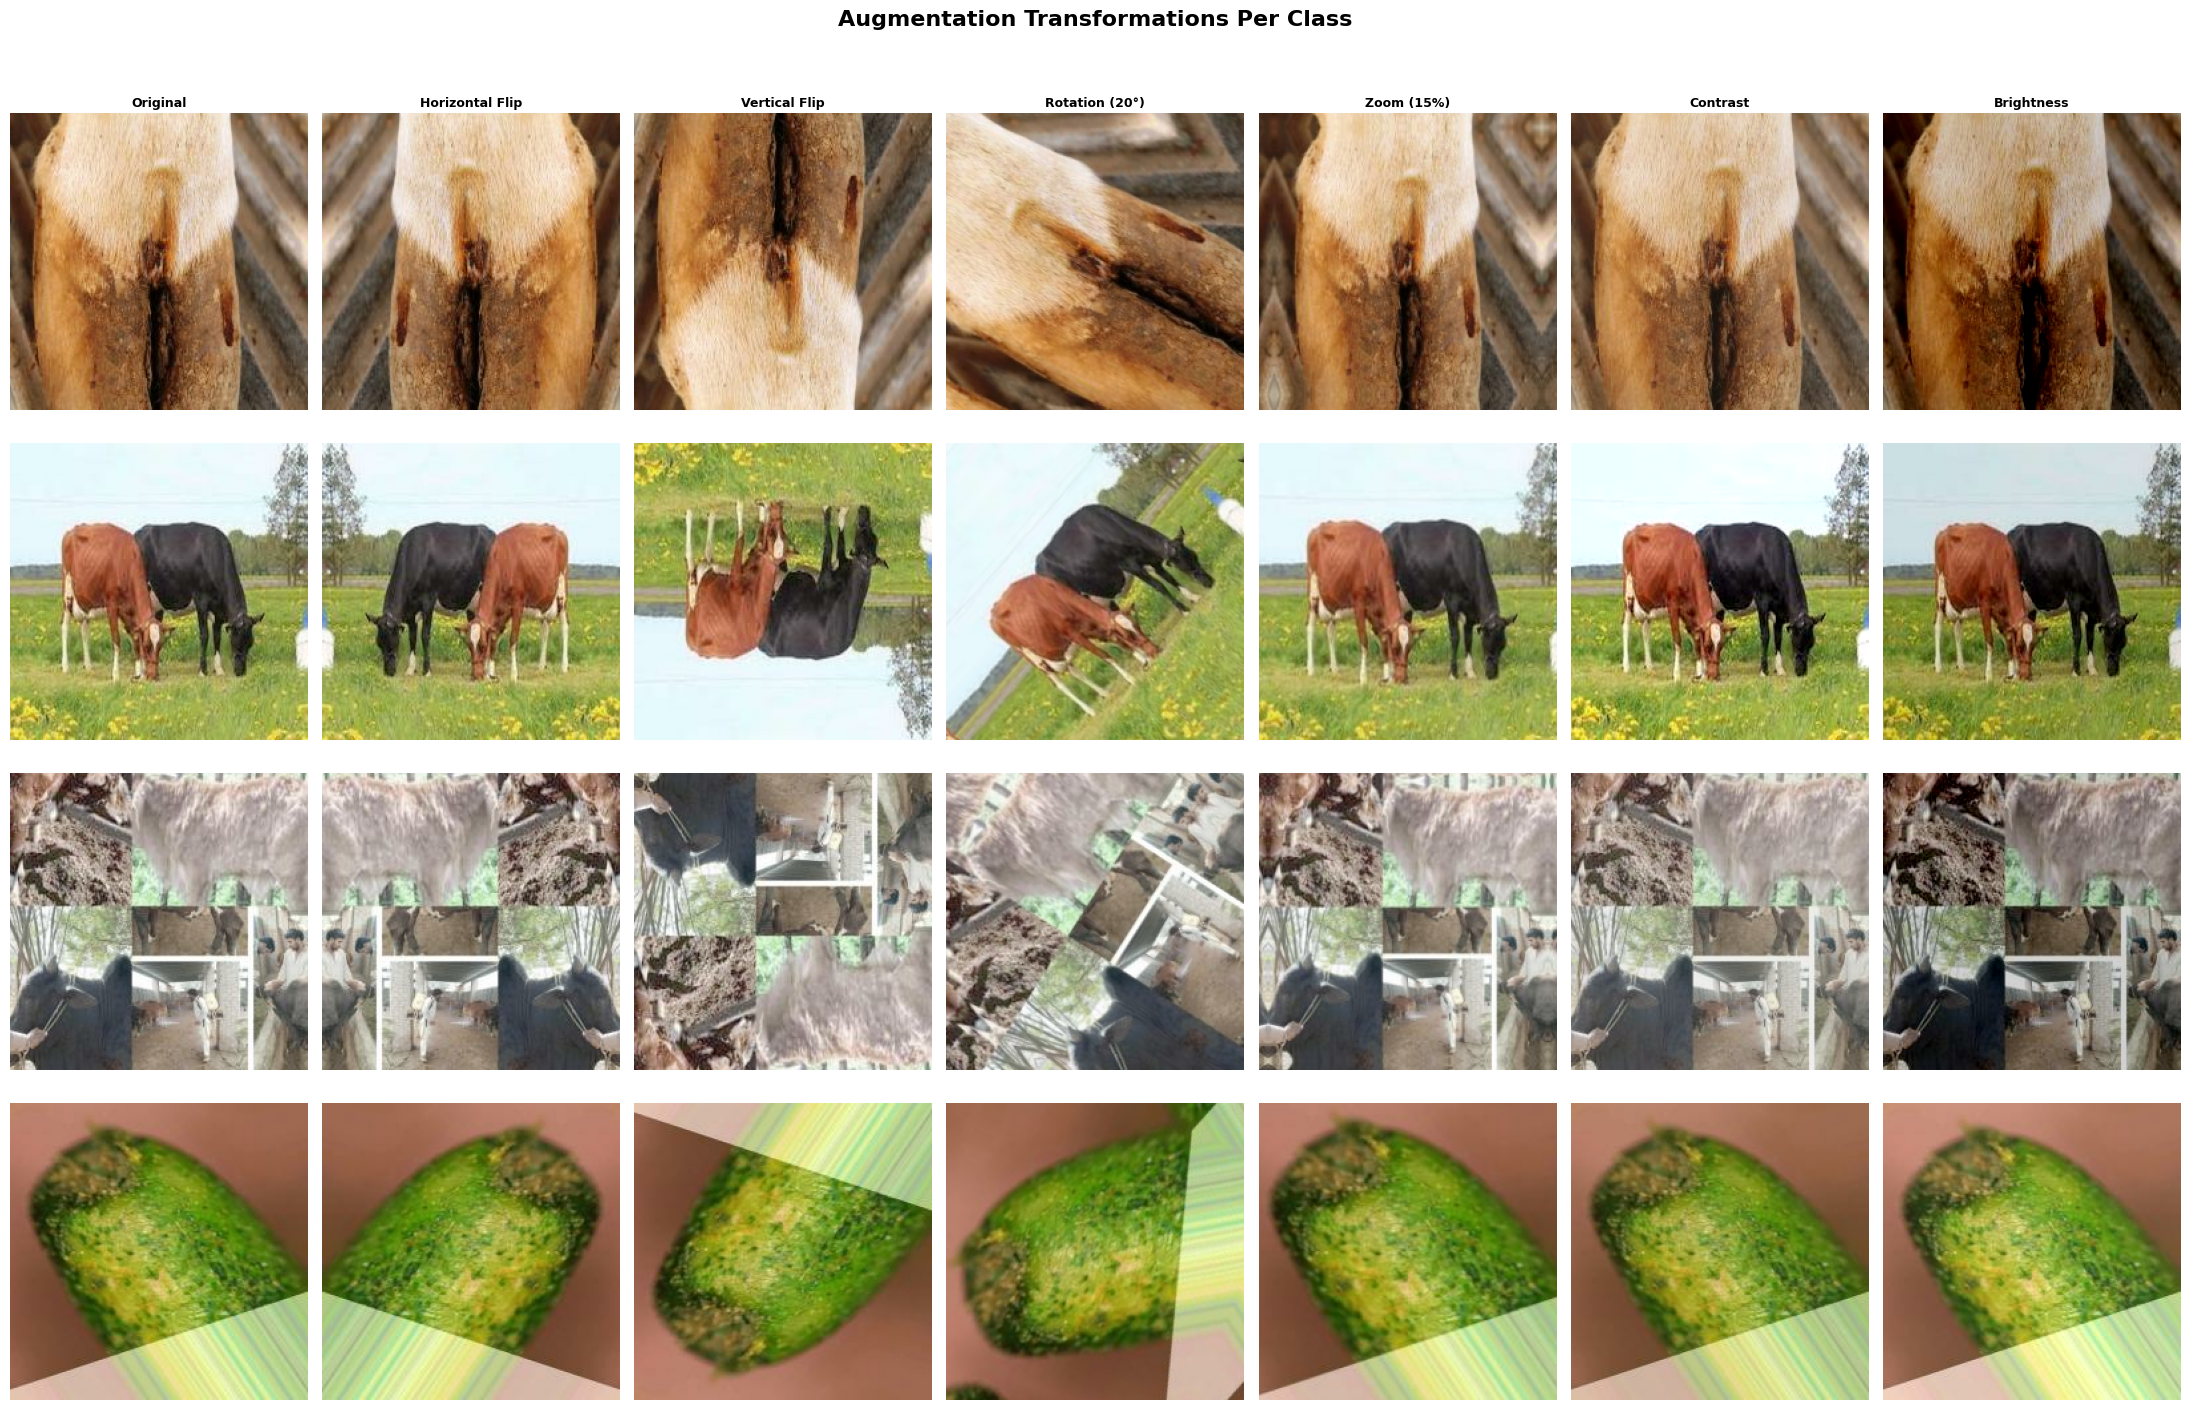

In [10]:
# Plot - one row per class, one column per transformation
fig, axes = plt.subplots(
    len(class_names), len(transforms),
    figsize=(22, 14)
)
fig.suptitle('Augmentation Transformations Per Class', 
             fontsize=16, fontweight='bold', y=1.02)

for row, class_name in enumerate(class_names):
    img = sample_images[class_name]
    
    for col, (transform_name, transform_fn) in enumerate(transforms):
        transformed = transform_fn(img).numpy().astype('uint8')
        
        axes[row, col].imshow(transformed)
        axes[row, col].axis('off')
        
        # Show transformation name on top row only
        if row == 0:
            axes[row, col].set_title(transform_name, fontsize=9, 
                                      fontweight='bold', pad=5)
        
        # Show class name on first column only
        if col == 0:
            axes[row, col].set_ylabel(class_name.upper(), fontsize=10,
                                       fontweight='bold', rotation=0,
                                       labelpad=70, va='center')
plt.tight_layout()
plt.show()

## 3. Model Architecture

### 3.1 Why EfficientNetB0?
EfficientNetB0 was chosen as the backbone over a custom CNN for three key reasons:
- **Pretrained on ImageNet** (1.2M images) - already understands edges, textures, and visual patterns
- **Fewer parameters to train** - reduces overfitting on our limited cattle disease dataset (2,800 images)
- **Built-in normalization** - no need for manual pixel rescaling

Training will follow a **two-phase strategy:**
- **Phase 1** - Freezing the EfficientNetB0 base, training only the new classification head
- **Phase 2** - Unfreezing the top 30 layers and fine-tuning with a very low learning rate

### 3.2 Building the Model

In [11]:
# Load pretrained base (weights from ImageNet, exclude top classification layer)
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze base model initially - fine-tune later in phase 2
base_model.trainable = False

# Build the full model
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                             

## 4. Model Training

### 4.1 Computing Class Weights

Class weights penalize the model more for misclassifying underrepresented classes. Since our dataset is balanced (700 images per class), all weights should be equal (1.0)

In [21]:
train_labels = []
for _, labels in training_set:
    train_labels.extend(np.argmax(labels.numpy(), axis=1))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = {int(k): float(v) for k, v in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0}


### 4.2 Callbacks
Three callbacks are used to control training:
- **EarlyStopping** - stops training when `val_loss` stops improving, restores best weights automatically
- **ModelCheckpoint** - saves the best model weights to disk during training
- **ReduceLROnPlateau** - reduces learning rate when `val_loss` plateaus to allow finer optimization

In [13]:
# Callbacks
callbacks = [
    # Stop training when val_loss stops improving (saves time + prevents overfitting)
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True, 
        verbose=1
    ),
    # Save the best model checkpoint to disk
    ModelCheckpoint(
        'best_model.h5',         
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True, 
        verbose=1
    ),
    # Reduce learning rate when val_loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

### 4.3 Phase 1: Train Head (Base Frozen)
The EfficientNetB0 base is completely frozen. Only the custom classification head (Dense + Dropout layers) is trained. A higher learning rate of `1e-3` is used since we are training from scratch.
This phase typically converges in 5–12 epochs thanks to EarlyStopping.

In [14]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 1: Training head with frozen base...")
history1 = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=15,  # EarlyStopping will stop this when ready
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Phase 1: Training head with frozen base...
Epoch 1/15
88/88 [==============================] - ETA: 0s - loss: 0.7624 - accuracy: 0.7725
Epoch 1: val_accuracy improved from -inf to 0.82441, saving model to best_model.h5
88/88 [==============================] - 166s 2s/step - loss: 0.7624 - accuracy: 0.7725 - val_loss: 0.4416 - val_accuracy: 0.8244 - lr: 0.0010
Epoch 2/15
88/88 [==============================] - ETA: 0s - loss: 0.4737 - accuracy: 0.8514
Epoch 2: val_accuracy improved from 0.82441 to 0.87793, saving model to best_model.h5
88/88 [==============================] - 137s 2s/step - loss: 0.4737 - accuracy: 0.8514 - val_loss: 0.3371 - val_accuracy: 0.8779 - lr: 0.0010
Epoch 3/15
88/88 [==============================] - ETA: 0s - loss: 0.4499 - accuracy: 0.8571
Epoch 3: val_accuracy did not improve from 0.87793
88/88 [==============================] - 153s 2s/step - loss: 0.4499 - accuracy: 0.8571 - val_loss: 0.3515 - val_accuracy: 0.8712 - lr: 0.0010
Epoch 4/15
88/88 [========

## 5. Phase 2 - Fine-Tuning (Unfreeze Top Layers)

In [15]:
# Unfreeze the top layers of the base model
# This adapts the pretrained features to specific cattle disease images
base_model.trainable = True

# Freeze all layers EXCEPT the last 30 (fine-tune only top portion)
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}")


model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 100x lower than phase 1 -  to avoid destroying pretrained weights
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 2: Fine-tuning top layers...")
history2 = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Trainable layers: 30 / 238
Phase 2: Fine-tuning top layers...
Epoch 1/20
88/88 [==============================] - ETA: 0s - loss: 0.2340 - accuracy: 0.9157
Epoch 1: val_accuracy did not improve from 0.92642
88/88 [==============================] - 174s 2s/step - loss: 0.2340 - accuracy: 0.9157 - val_loss: 0.2699 - val_accuracy: 0.9214 - lr: 1.0000e-05
Epoch 2/20
88/88 [==============================] - ETA: 0s - loss: 0.2145 - accuracy: 0.9200
Epoch 2: val_accuracy did not improve from 0.92642
88/88 [==============================] - 161s 2s/step - loss: 0.2145 - accuracy: 0.9200 - val_loss: 0.2648 - val_accuracy: 0.9231 - lr: 1.0000e-05
Epoch 3/20
88/88 [==============================] - ETA: 0s - loss: 0.2261 - accuracy: 0.9193
Epoch 3: val_accuracy did not improve from 0.92642
88/88 [==============================] - 142s 2s/step - loss: 0.2261 - accuracy: 0.9193 - val_loss: 0.2629 - val_accuracy: 0.9231 - lr: 1.0000e-05
Epoch 4/20
88/88 [==============================] - ETA: 0s - 

In [ ]:
#Load best weight

In [29]:
# Load the best saved weights back into the model
model.load_weights('best_model.h5')
print("✅ Best weights loaded successfully")

✅ Best weights loaded successfully


In [30]:
model.save_weights('cattle_final.weights.h5')
print('✅ Weights saved!')

✅ Weights saved!


In [31]:
import json

def fix_eager_tensor(obj):
    if hasattr(obj, 'numpy'):
        return obj.numpy().tolist()
    elif isinstance(obj, dict):
        return {k: fix_eager_tensor(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [fix_eager_tensor(i) for i in obj]
    return obj

config = fix_eager_tensor(model.get_config())

with open('cattle_final_archi.json', 'w') as f:
    json.dump(config, f)

print('✅ Architecture saved!')

✅ Architecture saved!


In [ ]:
#load model

In [32]:
import json
from tensorflow.keras.models import model_from_config

# Load architecture
with open('cattle_final_archi.json', 'r') as f:
    config = json.load(f)

# Rebuild model from config
model = tf.keras.Model.from_config(config)

# Load weights
model.load_weights('cattle_final.weights.h5')
print('✅ Model loaded successfully!')
print(f'   Total params: {model.count_params():,}')

✅ Model loaded successfully!
   Total params: 4,712,615


## 6. Visualize Training Results

In [ ]:
def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title(f'{title} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history(history1, "Phase 1 (Frozen Base)")
plot_history(history2, "Phase 2 (Fine-Tuning)")

## 7. Evaluate Final Model

In [34]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('✅ Model compiled!')

✅ Model compiled!


In [35]:
val_loss, val_acc = model.evaluate(validation_set)
print(f"\nVal Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f} ({val_acc*100:.1f}%)")

19/19 [==============================] - 23s 955ms/step - loss: 0.2436 - accuracy: 0.9348

Val Loss: 0.2436 | Val Accuracy: 0.9348 (93.5%)


### Classification Report 

              precision    recall  f1-score   support

         fmd       0.92      0.89      0.90       100
     healthy       0.95      0.93      0.94       271
  lumpy skin       0.94      0.97      0.95       177
    mastitis       0.87      0.92      0.89        50

    accuracy                           0.93       598
   macro avg       0.92      0.93      0.92       598
weighted avg       0.94      0.93      0.93       598



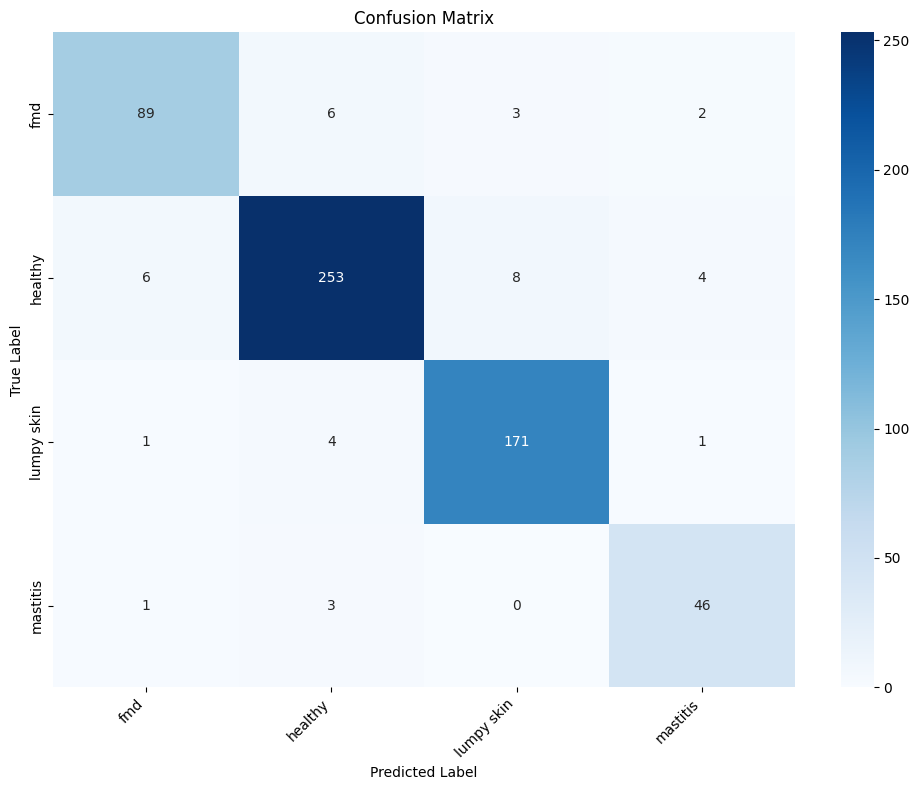

In [36]:
from sklearn.metrics import confusion_matrix, classification_report

y_true, y_pred = [], []
for images, labels in validation_set:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names,
            yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Testing Sample Images

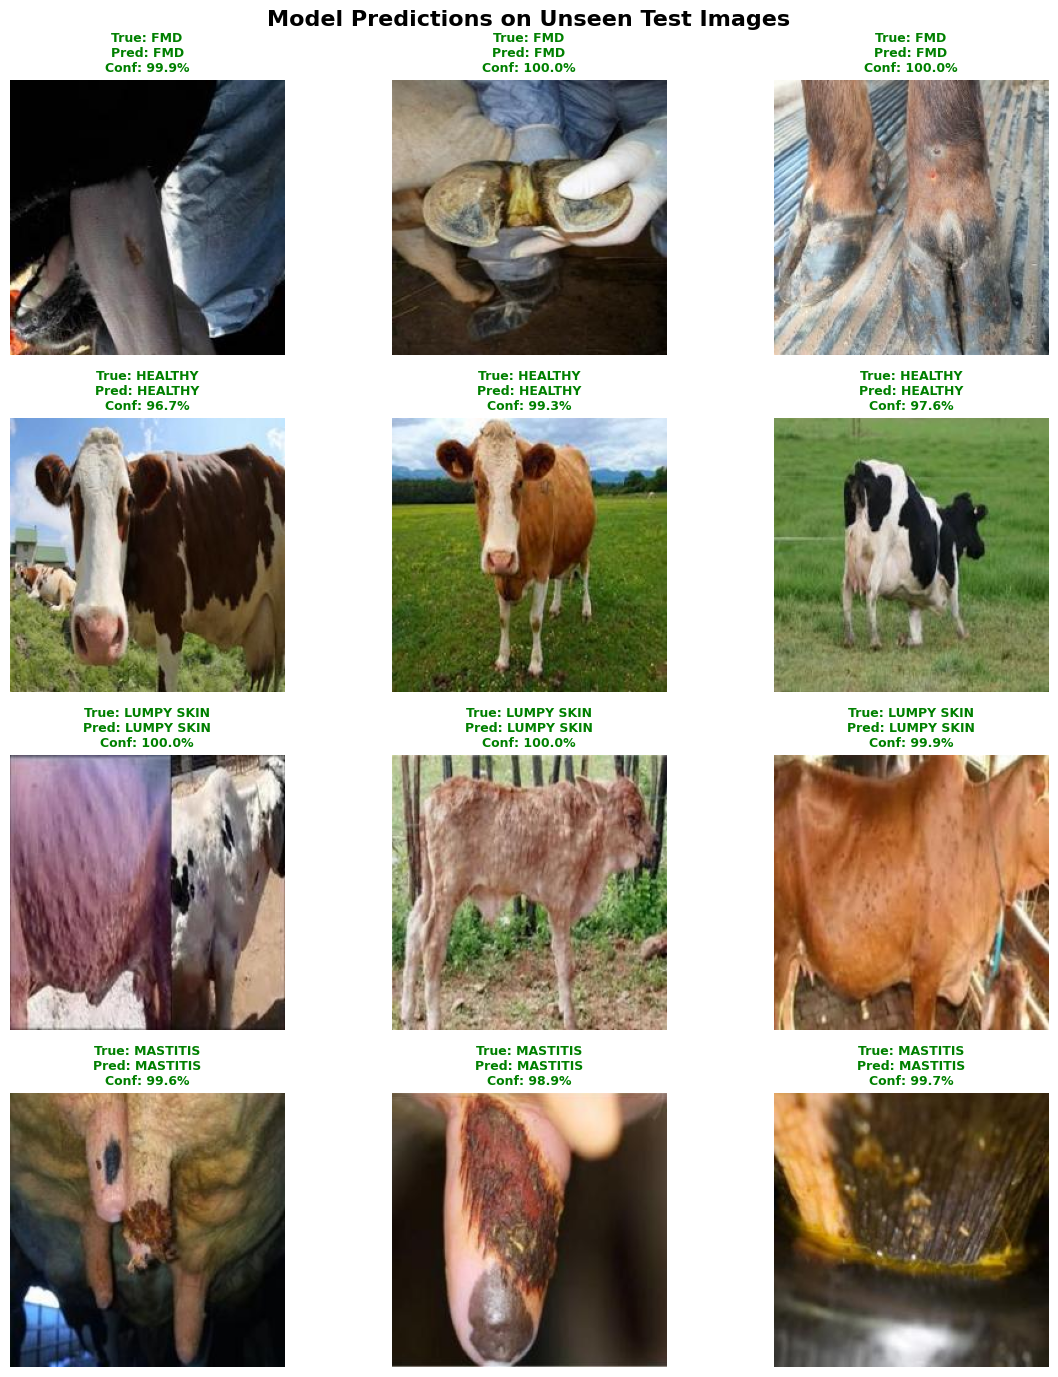

In [38]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import random

def predict_image(img_path):
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    predictions = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions) * 100
    return img, predicted_class, confidence, predictions[0]

# Pick 3 random images from each class in TEST folder
BASE_DIR = 'New-Cattle-Diseasee-3'
test_dir = os.path.join(BASE_DIR, 'test')

fig, axes = plt.subplots(len(class_names), 3, figsize=(12, 14))
fig.suptitle('Model Predictions on Unseen Test Images', fontsize=16, fontweight='bold')

for row, class_name in enumerate(class_names):
    class_path = os.path.join(test_dir, class_name)
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random_images = random.sample(images, min(3, len(images)))

    for col, img_file in enumerate(random_images):
        img_path = os.path.join(class_path, img_file)
        img, predicted, confidence, all_preds = predict_image(img_path)

        correct = predicted == class_name
        color = 'green' if correct else 'red'

        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        axes[row, col].set_title(
            f'True: {class_name.upper()}\n'
            f'Pred: {predicted.upper()}\n'
            f'Conf: {confidence:.1f}%',
            fontsize=9,
            color=color,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()